In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

In [3]:
arquivo = files.upload()

Saving leao-social.jpg to leao-social.jpg


array([[167, 166, 166, ..., 151, 152, 151],
       [156, 155, 155, ..., 155, 155, 154],
       [156, 156, 155, ..., 155, 155, 153],
       ...,
       [133, 135, 138, ..., 128, 131, 125],
       [133, 135, 138, ..., 128, 131, 125],
       [133, 135, 138, ..., 128, 131, 125]], dtype=uint8)
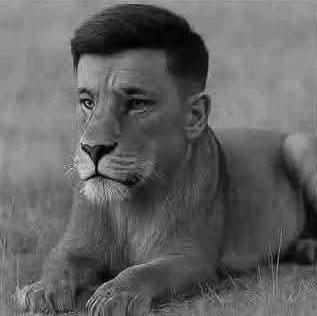

In [4]:
arquivo_imagem = next(iter(arquivo))
img_bgr = cv2.imread(arquivo_imagem)
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
img_gray

## Resposta

Conforme o número de bits da imagem é reduzido, ela vai perdendo qualidade progressivamente, o que faz ela perder qualidade cada vez mais. Em 1 bit, a imagem fica apenas na coloração preta e branca, e assim que os bits aumentam para 2, 4 e 8 bits os níveis de qualidade vão se recuperando e a intensidade dos detalhes ficam progressivamente melhor, com 8 bits toda a qualidade da imagem é preservada, mantendo sua qualidade original.

In [8]:
def quantizacao_imagem(imagem, bits):
    levels = 2 ** bits
    steps = 256 / levels

    index = np.floor(imagem / steps)

    imagem_quantizada = index * (255 / (levels - 1))

    return np.clip(imagem_quantizada, 0, 255).astype(np.uint8)


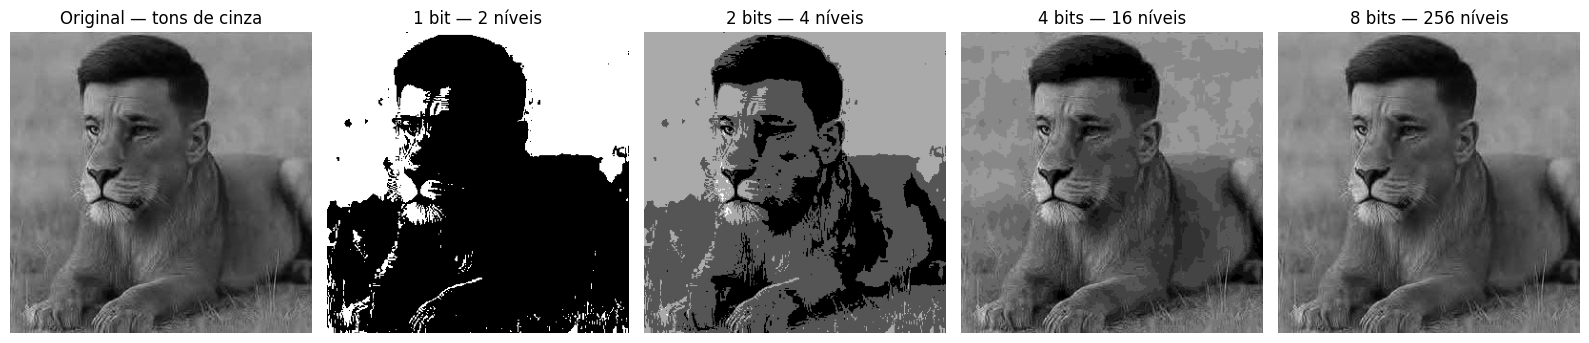

In [9]:
img_1bit = quantizacao_imagem(img_gray, 1)
img_2bit = quantizacao_imagem(img_gray, 2)
img_4bit = quantizacao_imagem(img_gray, 4)
img_8bit = quantizacao_imagem(img_gray, 8)

fig, ax = plt.subplots(1, 5, figsize=(16, 4))

ax[0].imshow(img_gray, cmap="gray", vmin=0, vmax=255)
ax[0].set_title("Original - tons de cinza")
ax[0].axis("off")

ax[1].imshow(img_1bit, cmap="gray", vmin=0, vmax=255)
ax[1].set_title("1 bit - 2 níveis")
ax[1].axis("off")

ax[2].imshow(img_2bit, cmap="gray", vmin=0, vmax=255)
ax[2].set_title("2 bits - 4 níveis")
ax[2].axis("off")

ax[3].imshow(img_4bit, cmap="gray", vmin=0, vmax=255)
ax[3].set_title("4 bits - 16 níveis")
ax[3].axis("off")

ax[4].imshow(img_8bit, cmap="gray", vmin=0, vmax=255)
ax[4].set_title("8 bits - 256 níveis")
ax[4].axis("off")

plt.tight_layout()
plt.savefig("quantizacao.png", dpi=300, bbox_inches="tight")
plt.show()